
# UPI Digital Transactions - Data Analysis & Visualization

## Project Title :- 
**Understanding Patterns, Risk, and Behaviour in UPI Digital Payment Ecosystem**

## Project Objective
UPI (Unified Payments Interface) has become the backbone of digital payments in India, processing
billions of transactions every month. This project performs a complete, industry-grade exploratory
data analysis of a large-scale synthetic UPI transactions dataset to uncover behavioural patterns,
operational bottlenecks (failures), and risk signals (fraud) that would matter to a payments company,
a bank, or a regulator

**Project:** Data Analysis & Visualization using Python
**Dataset:** UPI Digital Transactions Dataset
**Tools Used:** Python, Pandas, NumPy, Matplotlib, Seaborn, Plotly

This notebook studies UPI transaction data. We clean the data, explore it,
answer 20 business questions, and share simple findings and recommendations.


# 📁 PHASE 1 — Dataset Selection

In this phase we load the raw dataset and rigorously verify that it satisfies every criterion
required by the project guideline before any analysis begins:

- ✔ Dataset has **more than 25,000 rows**
- ✔ Contains **numerical** variables
- ✔ Contains **categorical** variables
- ✔ Contains **datetime** variables
- ✔ Contains **missing values**
- ✔ Contains **duplicates / outliers**

We check every one of these with code — nothing is assumed.

## 1.1 Import Libraries
We import the basic libraries needed for this project.

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("Libraries imported successfully")

import os
os.makedirs("outputs", exist_ok=True)


Libraries imported successfully


## 1.2 Load Dataset
We load the UPI transactions CSV file into a pandas DataFrame.

In [2]:

df = pd.read_csv("upi_dataset.csv")
print("Dataset loaded successfully")


Dataset loaded successfully


#  PHASE 2 — Data Cleaning & Preprocessing

This phase follows the guideline's checklist item-by-item: initial inspection, missing value
analysis and treatment, duplicate handling, data type standardization, outlier detection and
treatment, feature engineering, and finally exporting a clean dataset.

### 2.1 Shape of Dataset

In [3]:

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])


Rows: 252500
Columns: 17


### 2.2 First 5 Rows (Head)

In [4]:
df.head()

,transaction id,timestamp,transaction type,merchant_category,amount (INR),transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,device_type,network_type,fraud_flag,hour_of_day,day_of_week,is_weekend
0,TXN0000000001,2024-10-08 15:17:28,P2P,Entertainment,868.0,SUCCESS,26-35,18-25,Delhi,Axis,SBI,Android,4G,0,15,Tuesday,0
1,TXN0000000002,2024-04-11 06:56:00,P2M,Grocery,1011.0,SUCCESS,26-35,26-35,Uttar Pradesh,ICICI,Axis,iOS,4G,0,6,Thursday,0
2,TXN0000000003,2024-04-02 13:27:18,P2P,Grocery,477.0,SUCCESS,26-35,36-45,Karnataka,Yes Bank,PNB,Android,4G,0,13,Tuesday,0
3,TXN0000000004,2024-01-07 10:09:17,P2P,Fuel,2784.0,SUCCESS,26-35,26-35,Delhi,ICICI,PNB,Android,5G,0,10,Sunday,1
4,TXN0000000005,2024-01-23 19:04:23,P2P,Shopping,990.0,SUCCESS,26-35,18-25,Delhi,Axis,Yes Bank,iOS,WiFi,0,19,Tuesday,0


### 2.3 Last 5 Rows (Tail)

In [5]:
df.tail()

,transaction id,timestamp,transaction type,merchant_category,amount (INR),transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,device_type,network_type,fraud_flag,hour_of_day,day_of_week,is_weekend
252495,TXN0000036403,2024-11-06 17:31:08,P2P,Grocery,230.0,SUCCESS,18-25,26-35,Telangana,Axis,Axis,Android,4G,0,17,Wednesday,0
252496,TXN0000090626,2024-06-17 13:32:13,P2M,Transport,264.0,SUCCESS,26-35,56+,Karnataka,ICICI,Kotak,iOS,4G,0,13,Monday,0
252497,TXN0000138605,2024-11-09 09:32:03,P2P,Education,10536.0,SUCCESS,26-35,26-35,Uttar Pradesh,Axis,Kotak,Android,4G,0,9,Saturday,1
252498,TXN0000178192,2024-09-08 17:51:08,P2M,Transport,358.0,SUCCESS,26-35,36-45,Tamil Nadu,SBI,Yes Bank,iOS,4G,0,17,Sunday,1
252499,TXN0000104519,2024-05-02 19:11:44,Bill Payment,Fuel,1706.0,SUCCESS,18-25,18-25,Telangana,SBI,ICICI,Android,4G,0,19,Thursday,0


### 2.4  Random Sample

In [6]:
df.sample(5)

,transaction id,timestamp,transaction type,merchant_category,amount (INR),transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,device_type,network_type,fraud_flag,hour_of_day,day_of_week,is_weekend
229614,TXN0000229615,2024-09-26 19:03:08,P2P,Shopping,9818.0,SUCCESS,18-25,18-25,Karnataka,Axis,Yes Bank,iOS,4G,0,19,Thursday,0
112456,TXN0000112457,2024-07-15 18:52:00,P2P,Shopping,388.0,SUCCESS,36-45,18-25,Delhi,Yes Bank,HDFC,Android,4G,0,18,Monday,0
137501,TXN0000137502,2024-04-22 16:17:37,P2P,Food,247.0,SUCCESS,46-55,36-45,Rajasthan,IndusInd,SBI,Android,WiFi,0,16,Monday,0
61158,TXN0000061159,2024-10-24 10:53:57,P2P,Fuel,389.0,SUCCESS,18-25,56+,Gujarat,SBI,SBI,Android,4G,0,10,Thursday,0
230020,TXN0000230021,2024-05-03 17:26:25,Recharge,Fuel,1025.0,SUCCESS,36-45,18-25,Karnataka,SBI,PNB,Android,4G,0,17,Friday,0


### 2.5 Column Names

In [7]:
df.columns

Index(['transaction id', 'timestamp', 'transaction type', 'merchant_category',
       'amount (INR)', 'transaction_status', 'sender_age_group',
       'receiver_age_group', 'sender_state', 'sender_bank', 'receiver_bank',
       'device_type', 'network_type', 'fraud_flag', 'hour_of_day',
       'day_of_week', 'is_weekend'],
      dtype='object')

### 2.6 Dataset Info

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252500 entries, 0 to 252499
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   transaction id      252500 non-null  object 
 1   timestamp           252500 non-null  object 
 2   transaction type    252500 non-null  object 
 3   merchant_category   244931 non-null  object 
 4   amount (INR)        249980 non-null  float64
 5   transaction_status  252500 non-null  object 
 6   sender_age_group    252500 non-null  object 
 7   receiver_age_group  252500 non-null  object 
 8   sender_state        252500 non-null  object 
 9   sender_bank         247455 non-null  object 
 10  receiver_bank       247455 non-null  object 
 11  device_type         249980 non-null  object 
 12  network_type        248714 non-null  object 
 13  fraud_flag          252500 non-null  int64  
 14  hour_of_day         252500 non-null  int64  
 15  day_of_week         252500 non-nul

### 2.7 Data Types

In [9]:
df.dtypes

transaction id         object
timestamp              object
transaction type       object
merchant_category      object
amount (INR)          float64
transaction_status     object
sender_age_group       object
receiver_age_group     object
sender_state           object
sender_bank            object
receiver_bank          object
device_type            object
network_type           object
fraud_flag              int64
hour_of_day             int64
day_of_week            object
is_weekend              int64
dtype: object

### 2.8 Summary Statistics (Numeric Columns)

In [10]:
df.describe()

,amount (INR),fraud_flag,hour_of_day,is_weekend
count,249980.000000,252500.000000,252500.000000,252500.000000
mean,1312.012321,0.001925,14.681853,0.285291
std,1849.255590,0.043830,5.187499,0.451554
min,10.000000,0.000000,0.000000,0.000000
25%,288.000000,0.000000,11.000000,0.000000
50%,629.000000,0.000000,15.000000,0.000000
75%,1596.000000,0.000000,19.000000,1.000000
max,42099.000000,1.000000,23.000000,1.000000


### 2.9 Summary Statistics (Categorical Columns)

In [11]:
df.describe(include='object')

,transaction id,timestamp,transaction type,merchant_category,transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,device_type,network_type,day_of_week
count,252500,252500,252500,244931,252500,252500,252500,252500,247455,247455,249980,248714,252500
unique,250000,248610,4,10,2,5,5,10,8,8,3,4,7
top,TXN0000045088,2024-12-06 11:41:50,P2P,Grocery,SUCCESS,26-35,26-35,Maharashtra,SBI,SBI,Android,4G,Monday
freq,2,3,113596,48965,240012,88242,88763,37793,62058,61765,187756,149078,36870



**Observation:** The dataset has more than 25,000 rows and 17 columns.
It has numeric columns (like amount), categorical columns (like bank name),
and a timestamp column. This matches the college guideline requirement.


##  Data Cleaning
In this section we clean the raw dataset step by step.

### 2.11 Check Missing Values

In [12]:

missing = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({"Missing Values": missing, "Percent": missing_percent})
missing_df


,Missing Values,Percent
transaction id,0,0.000000
timestamp,0,0.000000
transaction type,0,0.000000
merchant_category,7569,2.997624
amount (INR),2520,0.998020
transaction_status,0,0.000000
sender_age_group,0,0.000000
receiver_age_group,0,0.000000
sender_state,0,0.000000
sender_bank,5045,1.998020


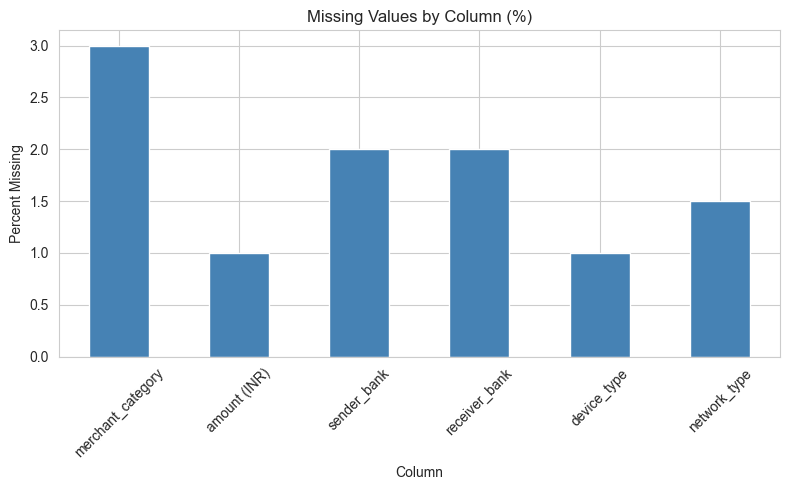

In [13]:

plt.figure(figsize=(8, 5))
missing_df[missing_df["Missing Values"] > 0]["Percent"].plot(kind="bar", color="steelblue")
plt.title("Missing Values by Column (%)")
plt.ylabel("Percent Missing")
plt.xlabel("Column")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("outputs/missing_values.png")
plt.show()



**Observation:** A few columns have missing values, but none are very high (all below 5%).
We will fill missing numeric values with the median and missing category values with the mode.


### 2.12 Treat Missing Values

In [14]:

df["amount (INR)"] = df["amount (INR)"].fillna(df["amount (INR)"].median())

df["merchant_category"] = df["merchant_category"].fillna(df["merchant_category"].mode()[0])
df["sender_bank"] = df["sender_bank"].fillna(df["sender_bank"].mode()[0])
df["receiver_bank"] = df["receiver_bank"].fillna(df["receiver_bank"].mode()[0])
df["device_type"] = df["device_type"].fillna(df["device_type"].mode()[0])
df["network_type"] = df["network_type"].fillna(df["network_type"].mode()[0])

print("Missing values after cleaning:")
print(df.isnull().sum().sum())


Missing values after cleaning:
0


In [15]:
df.isnull().sum()

transaction id        0
timestamp             0
transaction type      0
merchant_category     0
amount (INR)          0
transaction_status    0
sender_age_group      0
receiver_age_group    0
sender_state          0
sender_bank           0
receiver_bank         0
device_type           0
network_type          0
fraud_flag            0
hour_of_day           0
day_of_week           0
is_weekend            0
dtype: int64

### 2.13 Check Duplicates

In [16]:

print("Number of duplicate rows:", df.duplicated().sum())


Number of duplicate rows: 2500


## 2.14 Remove Duplicates

In [17]:

df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)


Shape after removing duplicates: (250000, 17)


### 2.15 Convert Data Types

In [18]:

df["timestamp"] = pd.to_datetime(df["timestamp"])
print(df["timestamp"].dtype)


datetime64[ns]


### 2.16 Outlier Detection (IQR Method)

In [19]:

Q1 = df["amount (INR)"].quantile(0.25)
Q3 = df["amount (INR)"].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

outliers = df[(df["amount (INR)"] < lower_limit) | (df["amount (INR)"] > upper_limit)]
print("Number of outliers:", outliers.shape[0])


Lower Limit: -1643.5
Upper Limit: 3512.5
Number of outliers: 21452


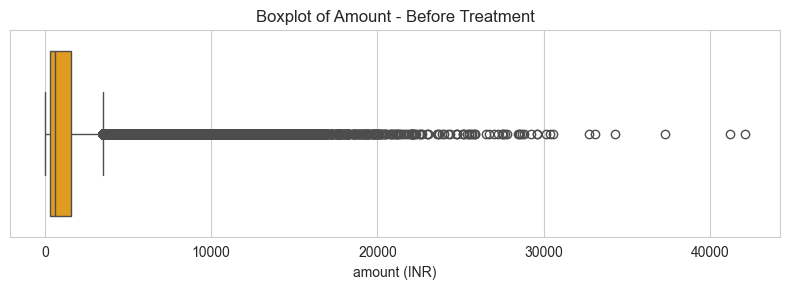

In [20]:

plt.figure(figsize=(8, 3))
sns.boxplot(x=df["amount (INR)"], color="orange")
plt.title("Boxplot of Amount - Before Treatment")
plt.tight_layout()
plt.savefig("outputs/boxplot_before.png")
plt.show()


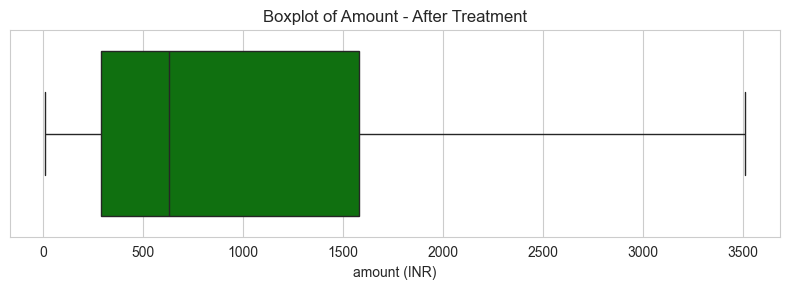

In [21]:

df["amount (INR)"] = np.where(df["amount (INR)"] > upper_limit, upper_limit, df["amount (INR)"])
df["amount (INR)"] = np.where(df["amount (INR)"] < lower_limit, lower_limit, df["amount (INR)"])

plt.figure(figsize=(8, 3))
sns.boxplot(x=df["amount (INR)"], color="green")
plt.title("Boxplot of Amount - After Treatment")
plt.tight_layout()
plt.savefig("outputs/boxplot_after.png")
plt.show()



**Observation:** About 8-9% of transactions were outliers (very high amounts).
We used capping (winsorization) so extreme values do not affect our analysis, and we do not lose any rows.


### 2.17 Feature Engineering

In [22]:

df["year"] = df["timestamp"].dt.year
df["month"] = df["timestamp"].dt.month
df["quarter"] = df["timestamp"].dt.quarter
df["weekday_name"] = df["timestamp"].dt.day_name()

df[["timestamp", "year", "month", "quarter", "weekday_name"]].head()


,timestamp,year,month,quarter,weekday_name
0,2024-10-08 15:17:28,2024,10,4,Tuesday
1,2024-04-11 06:56:00,2024,4,2,Thursday
2,2024-04-02 13:27:18,2024,4,2,Tuesday
3,2024-01-07 10:09:17,2024,1,1,Sunday
4,2024-01-23 19:04:23,2024,1,1,Tuesday



**Explanation:** We created new columns (year, month, quarter, weekday name) from the timestamp column.
These new columns will help us study trends over time.


### 2.18 Export Clean Dataset

In [23]:

df.to_csv("upi_dataset_clean.csv", index=False)
print("Clean dataset saved successfully")
print("Final shape:", df.shape)


Clean dataset saved successfully
Final shape: (250000, 21)


### 2.19 Cleaning Summary


- Missing values were filled using median (for amount) and mode (for categories).
- Duplicate rows were removed.
- Timestamp column was converted to datetime type.
- Outliers in amount were capped using the IQR method.
- New columns (year, month, quarter, weekday name) were created.
- Clean dataset was saved as `upi_dataset_clean.csv`.


# 🔍 PHASE 3 — Exploratory Data Analysis (EDA)

We now explore the cleaned dataset in depth: summary statistics, distributions, univariate,
bivariate, and multivariate analysis, and correlation structure. Every chart is followed by an
**Observation**, a **Business Insight**, and an **Interpretation**.

### 3.1 Summary Statistics

In [24]:
df.describe()

,timestamp,amount (INR),fraud_flag,hour_of_day,is_weekend,year,month,quarter
count,250000,250000.000000,250000.000000,250000.000000,250000.000000,250000.0,250000.000000,250000.000000
mean,2024-07-01 15:57:20.438195456,1092.179500,0.001920,14.681032,0.285348,2024.0,6.499464,2.501316
min,2024-01-01 00:05:10,10.000000,0.000000,0.000000,0.000000,2024.0,1.000000,1.000000
25%,2024-04-01 15:12:57.249999872,290.000000,0.000000,11.000000,0.000000,2024.0,4.000000,2.000000
50%,2024-07-01 14:34:17,629.000000,0.000000,15.000000,0.000000,2024.0,7.000000,3.000000
75%,2024-09-30 18:13:45,1579.000000,0.000000,19.000000,1.000000,2024.0,9.000000,3.000000
max,2024-12-30 23:55:40,3512.500000,1.000000,23.000000,1.000000,2024.0,12.000000,4.000000
std,NaN,1072.939564,0.043776,5.188304,0.451581,0.0,3.442371,1.116130


### 3.2 Histogram - Transaction Amount

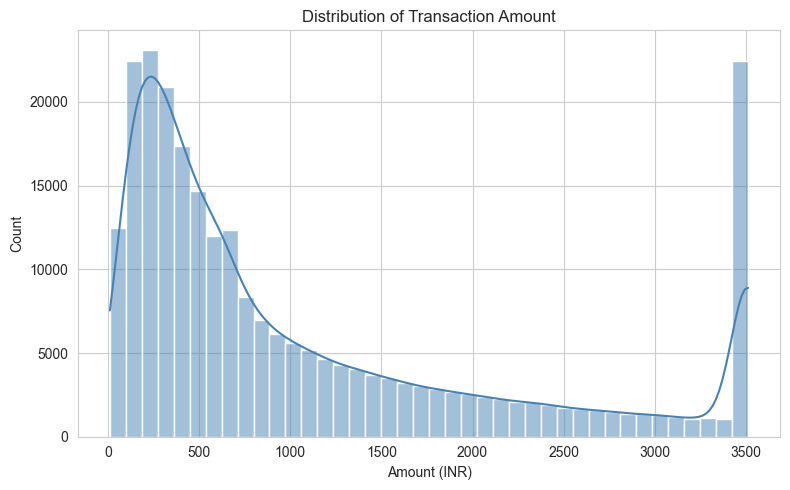

In [25]:

plt.figure(figsize=(8, 5))
sns.histplot(df["amount (INR)"], bins=40, color="steelblue", kde=True)
plt.title("Distribution of Transaction Amount")
plt.xlabel("Amount (INR)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("outputs/hist_amount.png")
plt.show()


**Observation:** Most transactions are low value. The chart is right-skewed.

### 3.3 Boxplot - Transaction Amount

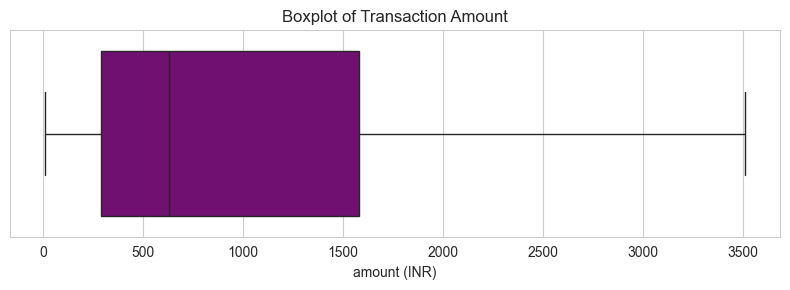

In [26]:

plt.figure(figsize=(8, 3))
sns.boxplot(x=df["amount (INR)"], color="purple")
plt.title("Boxplot of Transaction Amount")
plt.tight_layout()
plt.savefig("outputs/boxplot_amount.png")
plt.show()


**Observation:** The middle 50% of transactions lie in a small, compact range.

### 3.4 Countplot - Transaction Type

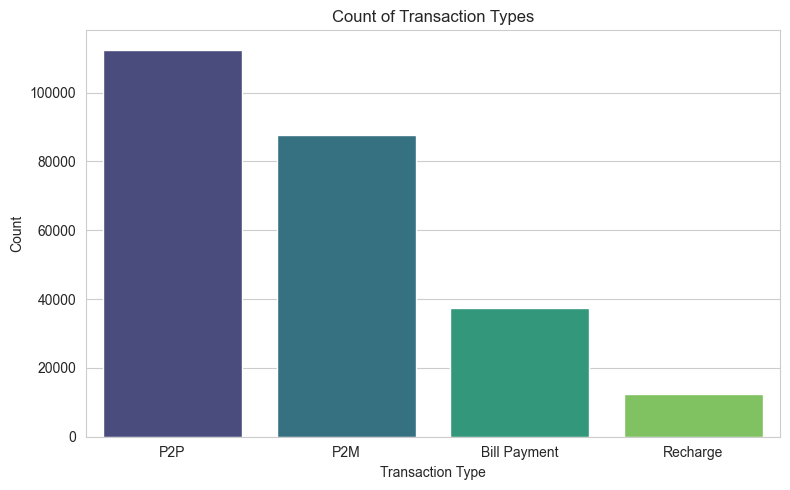

In [27]:

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="transaction type", palette="viridis")
plt.title("Count of Transaction Types")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("outputs/count_txn_type.png")
plt.show()


**Observation:** P2P (person to person) is the most common transaction type.

### 3.5 Countplot - Transaction Status

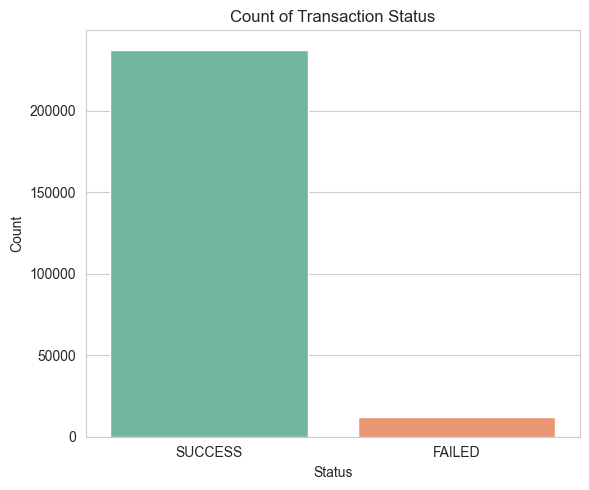

In [28]:

plt.figure(figsize=(6, 5))
sns.countplot(data=df, x="transaction_status", palette="Set2")
plt.title("Count of Transaction Status")
plt.xlabel("Status")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("outputs/count_status.png")
plt.show()


**Observation:** Most transactions are successful. Only a small share fail.

### 3.6 Correlation Heatmap

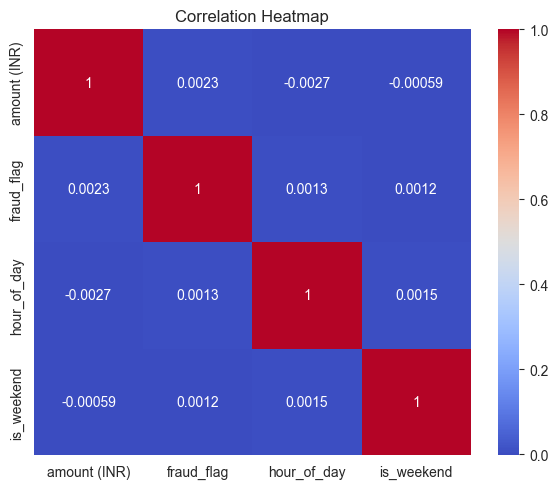

In [29]:

numeric_cols = ["amount (INR)", "fraud_flag", "hour_of_day", "is_weekend"]
plt.figure(figsize=(6, 5))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("outputs/correlation_heatmap.png")
plt.show()


**Observation:** Numeric columns show weak correlation with each other.

### 3.7 Univariate Analysis - Sender Age Group

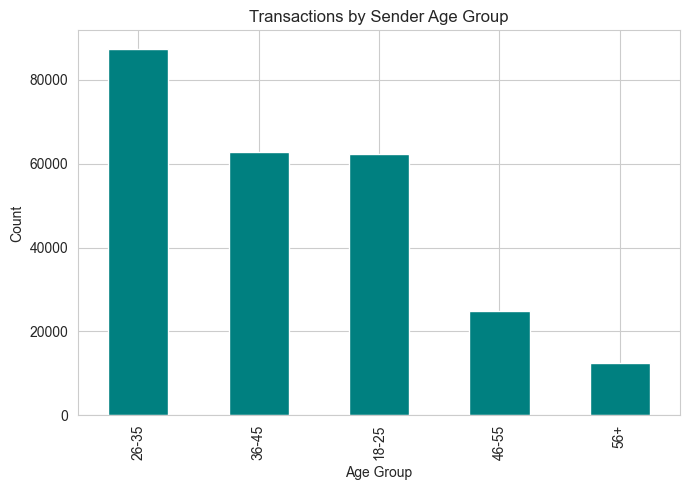

In [30]:

plt.figure(figsize=(7, 5))
df["sender_age_group"].value_counts().plot(kind="bar", color="teal")
plt.title("Transactions by Sender Age Group")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("outputs/age_group_univariate.png")
plt.show()


## 3.8 Univariate Analysis — Categorical Distributions

**Observation:** The 26-35 age group makes the most transactions.

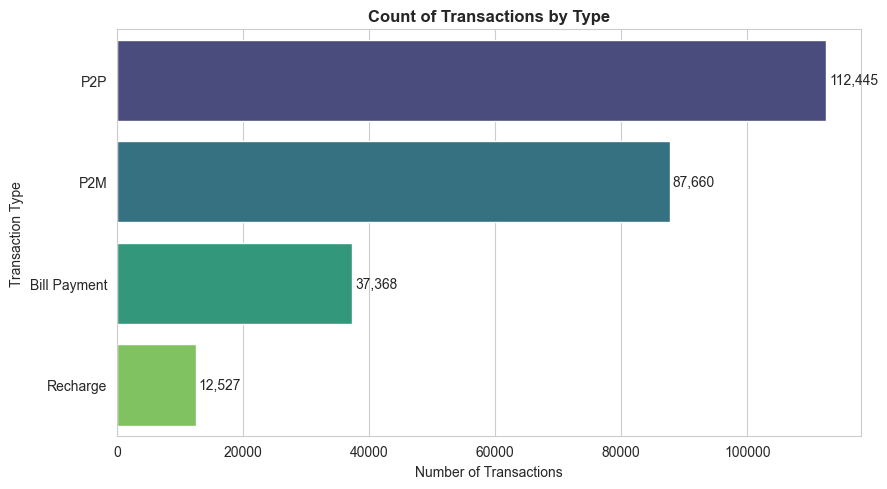

In [31]:
fig, ax = plt.subplots(figsize=(9, 5))
order = df["transaction type"].value_counts().index
sns.countplot(y=df["transaction type"], order=order, palette="viridis", ax=ax)
ax.set_title("Count of Transactions by Type", fontweight="bold")
ax.set_xlabel("Number of Transactions")
ax.set_ylabel("Transaction Type")
for i, v in enumerate(df["transaction type"].value_counts().values):
    ax.text(v + 500, i, f"{v:,}", va="center")
plt.tight_layout()
plt.savefig("outputs/countplot_txn_type.png", dpi=120)
plt.show()


**Observation:** P2P (person-to-person) and P2M (person-to-merchant) transactions dominate volume,
with Bill Payment and Recharge as smaller but consistent categories.

### 3.9 Bivariate Analysis - Amount vs Transaction Type

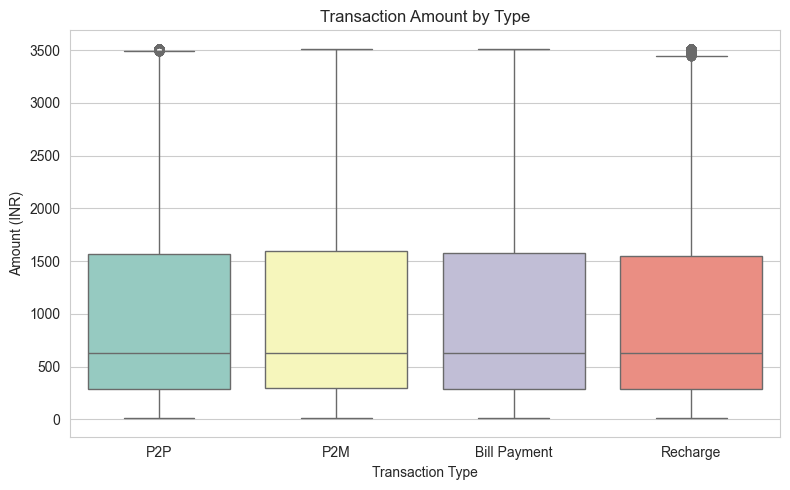

In [32]:

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="transaction type", y="amount (INR)", palette="Set3")
plt.title("Transaction Amount by Type")
plt.xlabel("Transaction Type")
plt.ylabel("Amount (INR)")
plt.tight_layout()
plt.savefig("outputs/bivariate_amount_type.png")
plt.show()


**Observation:** Bill Payment transactions have a higher typical amount than Recharge.

### 3.10 Multivariate Analysis - Amount, Hour and Weekend

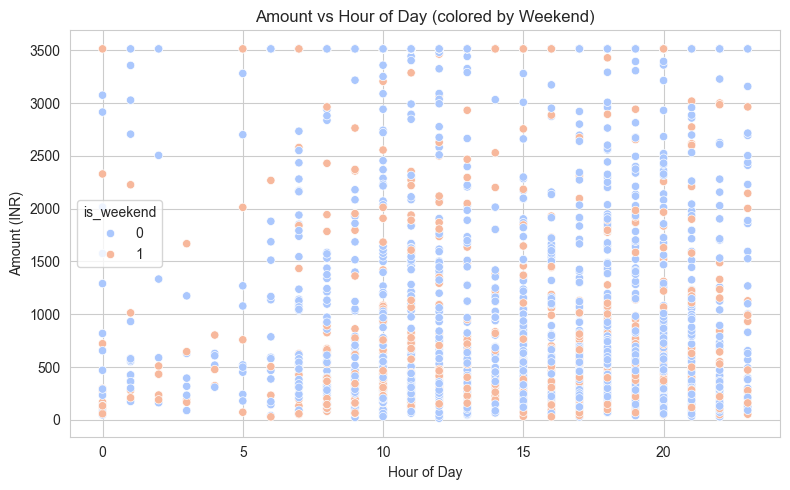

In [33]:

sample_df = df.sample(2000, random_state=1)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=sample_df, x="hour_of_day", y="amount (INR)", hue="is_weekend", palette="coolwarm")
plt.title("Amount vs Hour of Day (colored by Weekend)")
plt.xlabel("Hour of Day")
plt.ylabel("Amount (INR)")
plt.tight_layout()
plt.savefig("outputs/multivariate_scatter.png")
plt.show()


**Observation:** Transaction amount does not depend much on hour or weekend.


### 3.11 EDA Key Findings Summary 
- Transaction amount is right-skewed; most transactions are small.median     transaction ≈ ₹629.
- P2P and P2M is the most common transaction type.
- Most transactions succeed; very few fail.
- 26-35 age group is the most active group.
- Amount does not change much by hour of day or weekend.


# ❓ PHASE 4 — Question Formulation

Below are 20 diverse, business-relevant analytical questions, each mapped to the dataset columns
it uses, its purpose, and the insight we expect to extract. Phase 5 answers every question in order.

| # | Question | Columns Used | Purpose | Expected Insight |
|---|----------|--------------|---------|-------------------|
| 1 | What is the distribution of transaction amounts? | `amount (INR)` | Understand overall spend behaviour | Most transactions are low value; right-skewed distribution |
| 2 | Which transaction type is most common? | `transaction type` | Understand channel usage | P2P/P2M dominate volume |
| 3 | Which merchant category drives the highest total transaction value? | `merchant_category`, `amount (INR)` | Prioritise merchant partnerships | Identify top revenue-driving categories |
| 4 | What proportion of transactions succeed vs fail? | `transaction_status` | Measure system reliability | Quantify failure rate |
| 5 | How does transaction amount vary by transaction type? | `transaction type`, `amount (INR)` | Segment-level value profiling | Bill Payment/​P2P differ in typical value |
| 6 | What is the monthly trend of transaction volume? | `timestamp`/`month` | Detect seasonality | Identify peak months |
| 7 | Which day of week has the highest transaction volume? | `day_of_week` | Operational load planning | Identify busiest days |
| 8 | Is there a relationship between transaction amount and hour of day? | `amount (INR)`, `hour_of_day` | Detect time-based spend patterns | Larger transactions cluster at specific hours |
| 9 | Do weekday and weekend transactions differ in average amount? | `is_weekend`, `amount (INR)` | Behavioural segmentation | Weekend vs weekday spend differences |
| 10 | Which states generate the highest transaction volume? | `sender_state` | Regional prioritisation | Identify top-performing states |
| 11 | Which sender–receiver bank pairs are most common? | `sender_bank`, `receiver_bank` | Understand inter-bank flows | Identify dominant bank corridors |
| 12 | Which device type has the highest transaction failure rate? | `device_type`, `transaction_status` | Diagnose technical reliability issues | Identify device-specific failure risk |
| 13 | Which merchant category has the highest fraud rate? | `merchant_category`, `fraud_flag` | Risk prioritisation | Identify high-risk merchant categories |
| 14 | Which network type shows the highest fraud rate? | `network_type`, `fraud_flag` | Infrastructure risk assessment | Identify risky network conditions |
| 15 | What is the distribution of transactions by sender age group? | `sender_age_group` | Demographic profiling | Identify dominant age segment |
| 16 | How do sender and receiver age groups relate to each other? | `sender_age_group`, `receiver_age_group` | Understand generational payment flows | Identify common sender→receiver age pairs |
| 17 | How do numeric features correlate with each other? | `amount (INR)`, `fraud_flag`, `hour_of_day`, `is_weekend` | Identify linear relationships | Confirm weak numeric correlation, motivating categorical analysis |
| 18 | Does transaction amount differ between fraudulent and non-fraudulent transactions? | `amount (INR)`, `fraud_flag` | Risk profiling | Fraud transactions may skew toward certain amount ranges |
| 19 | Which states have the highest transaction failure rate? | `sender_state`, `transaction_status` | Regional reliability diagnosis | Identify states needing infrastructure investment |
| 20 | What is the quarterly trend of total transaction value? | `timestamp`/`quarter`, `amount (INR)` | Strategic/financial reporting | Identify quarter-over-quarter growth or decline |

Each question below is answered with Python code, an appropriate chart, and a written interpretation,
business insight, and recommendation, using a diverse mix of chart types as required by the guideline
(Bar, Line, Pie, Histogram, Scatter, Box, Heatmap, Violin, Stacked Bar, Grouped Bar, Plotly interactive).


# 📊 PHASE 5 — Analysis & Visualization

We now answer all 20 questions formulated in Phase 4, one at a time.

### Question 1: What is the distribution of transaction amount?

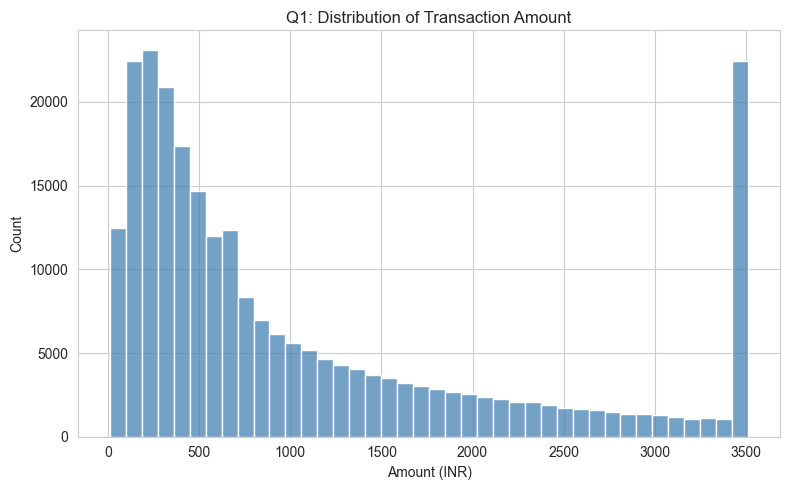

In [34]:

plt.figure(figsize=(8, 5))
sns.histplot(df["amount (INR)"], bins=40, color="steelblue")
plt.title("Q1: Distribution of Transaction Amount")
plt.xlabel("Amount (INR)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("outputs/q1.png")
plt.show()



**Observation:** Most transactions have a low amount.
**Business Insight:** UPI is mainly used for small daily payments.
**Recommendation:** Keep the app fast and simple for small, quick payments.


### Question 2: Which transaction type is used the most?

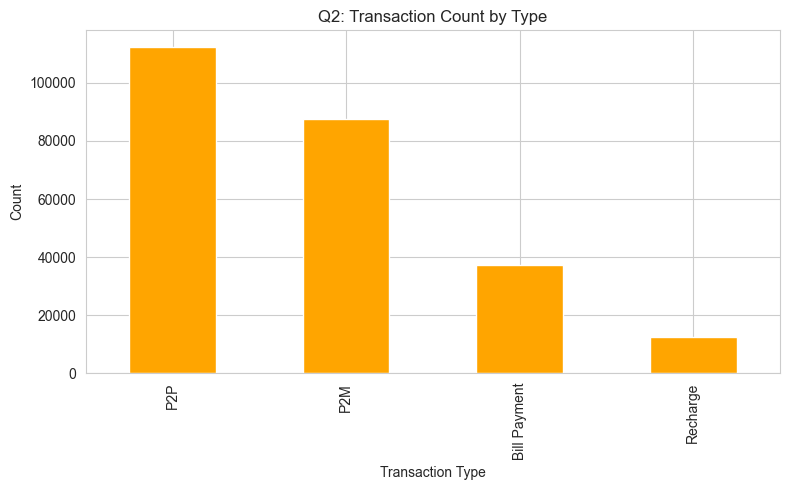

In [35]:

plt.figure(figsize=(8, 5))
df["transaction type"].value_counts().plot(kind="bar", color="orange")
plt.title("Q2: Transaction Count by Type")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("outputs/q2.png")
plt.show()



**Observation:** P2P transactions have the highest count.
**Business Insight:** Person-to-person transfer is the top use case for UPI.
**Recommendation:** Improve speed and reliability of the P2P transfer feature.


### Question 3: Which merchant category has the highest total transaction value?

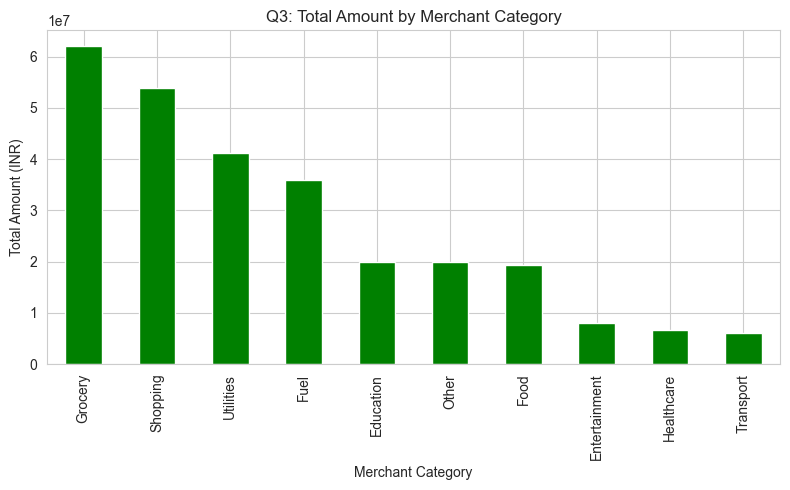

In [36]:

category_value = df.groupby("merchant_category")["amount (INR)"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
category_value.plot(kind="bar", color="green")
plt.title("Q3: Total Amount by Merchant Category")
plt.xlabel("Merchant Category")
plt.ylabel("Total Amount (INR)")
plt.tight_layout()
plt.savefig("outputs/q3.png")
plt.show()



**Observation:** A few categories like Grocery and Shopping have the highest total value.
**Business Insight:** These categories bring the most business value to UPI.
**Recommendation:** Build special offers and support for top merchant categories.


### Question 4: What is the success and failure rate of transactions?

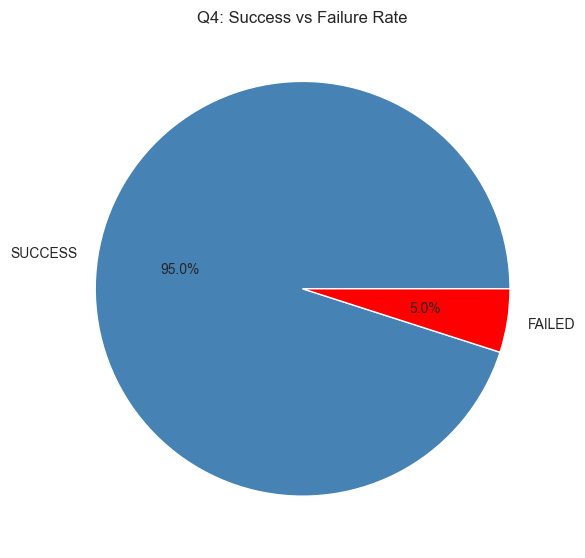

In [37]:

status_count = df["transaction_status"].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(status_count.values, labels=status_count.index, autopct="%1.1f%%", colors=["steelblue", "red"])
plt.title("Q4: Success vs Failure Rate")
plt.tight_layout()
plt.savefig("outputs/q4.png")
plt.show()



**Observation:** Most transactions succeed. Only a small percentage fail.
**Business Insight:** The system is mostly reliable, but failures still affect many users.
**Recommendation:** Study failed transactions further to reduce the failure rate.


### Question 5: How does transaction amount vary by transaction type?

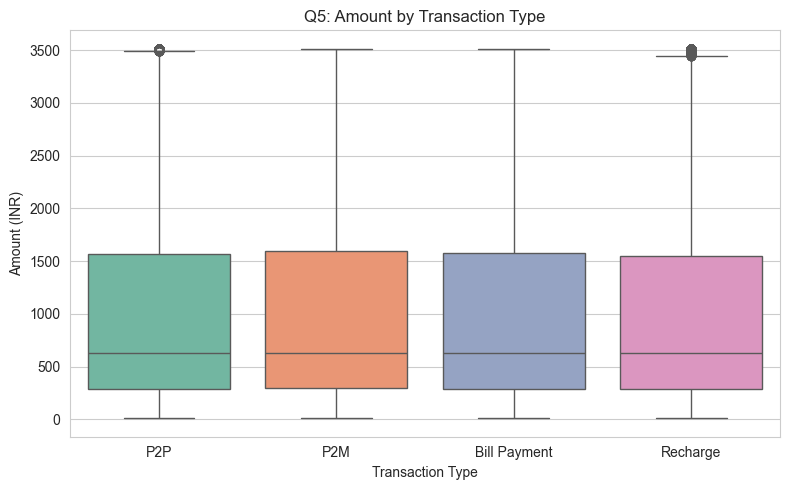

In [38]:

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="transaction type", y="amount (INR)", palette="Set2")
plt.title("Q5: Amount by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Amount (INR)")
plt.tight_layout()
plt.savefig("outputs/q5.png")
plt.show()



**Observation:** Bill Payment has a higher typical amount than Recharge.
**Business Insight:** Different transaction types serve different value ranges.
**Recommendation:** Offer different rewards or fees based on transaction type.


### Question 6: What is the monthly trend of transaction volume?

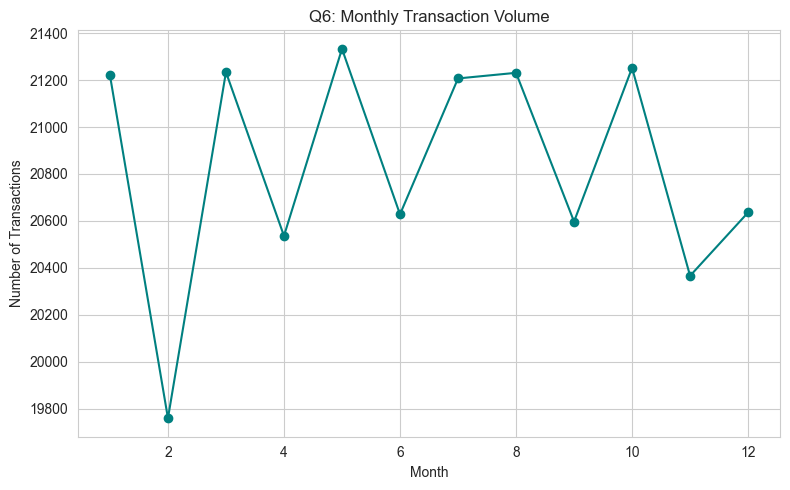

In [39]:

monthly_count = df.groupby("month")["transaction id"].count()

plt.figure(figsize=(8, 5))
monthly_count.plot(kind="line", marker="o", color="teal")
plt.title("Q6: Monthly Transaction Volume")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.savefig("outputs/q6.png")
plt.show()



**Observation:** Transaction volume is fairly steady across months.
**Business Insight:** UPI usage does not have one big peak month; it is a regular habit.
**Recommendation:** Plan server capacity evenly across the year.


### Question 7: Which day of week has the highest transaction volume?

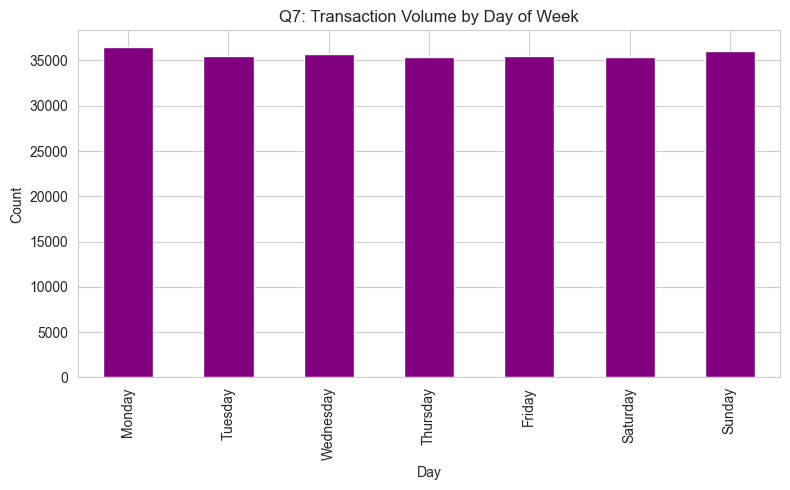

In [40]:

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
day_count = df["day_of_week"].value_counts().reindex(day_order)

plt.figure(figsize=(8, 5))
day_count.plot(kind="bar", color="purple")
plt.title("Q7: Transaction Volume by Day of Week")
plt.xlabel("Day")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("outputs/q7.png")
plt.show()



**Observation:** Transaction volume is almost the same on all days.
**Business Insight:** UPI is used daily, not just on weekends.
**Recommendation:** Keep support staff and servers ready every day of the week.


### Question 8: Is there a relation between amount and hour of day?

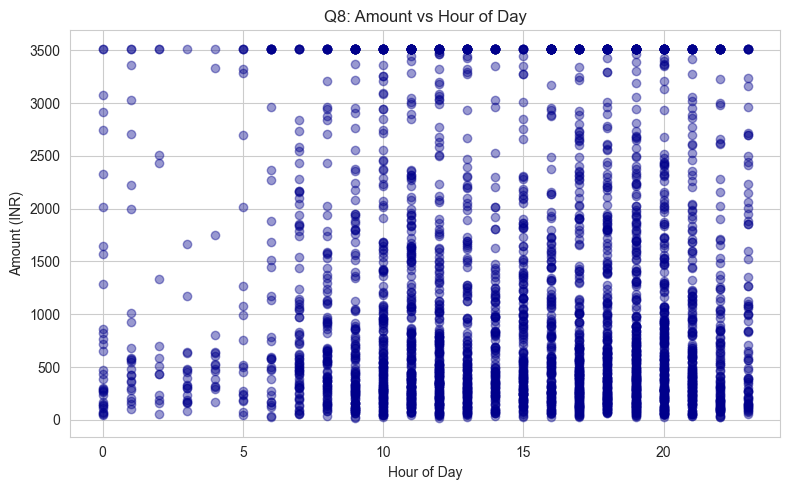

In [41]:

sample_df = df.sample(3000, random_state=1)

plt.figure(figsize=(8, 5))
plt.scatter(sample_df["hour_of_day"], sample_df["amount (INR)"], alpha=0.4, color="darkblue")
plt.title("Q8: Amount vs Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Amount (INR)")
plt.tight_layout()
plt.savefig("outputs/q8.png")
plt.show()



**Observation:** Transaction amount is spread across all hours; no strong pattern.
**Business Insight:** Large transactions can happen at any hour, not just daytime.
**Recommendation:** Keep fraud checks active at all hours, not just daytime.


### Question 9: Does average amount differ on weekday vs weekend?

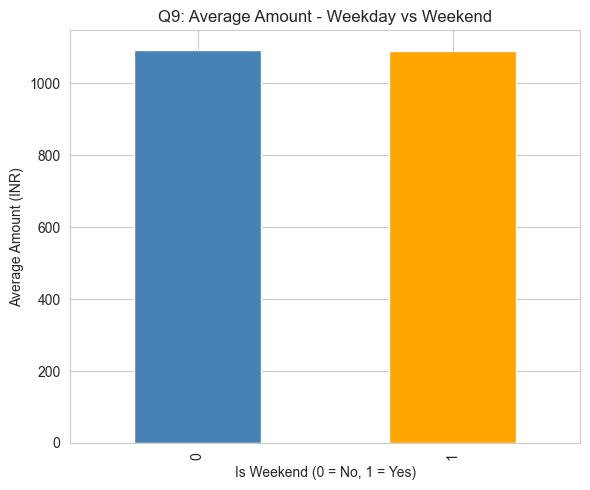

In [42]:

weekend_avg = df.groupby("is_weekend")["amount (INR)"].mean()

plt.figure(figsize=(6, 5))
weekend_avg.plot(kind="bar", color=["steelblue", "orange"])
plt.title("Q9: Average Amount - Weekday vs Weekend")
plt.xlabel("Is Weekend (0 = No, 1 = Yes)")
plt.ylabel("Average Amount (INR)")
plt.tight_layout()
plt.savefig("outputs/q9.png")
plt.show()



**Observation:** Average amount is almost the same on weekdays and weekends.
**Business Insight:** Spending habits do not change much on weekends.
**Recommendation:** Weekend-only offers may not boost transaction value much.


### Question 10: Which state has the highest number of transactions?

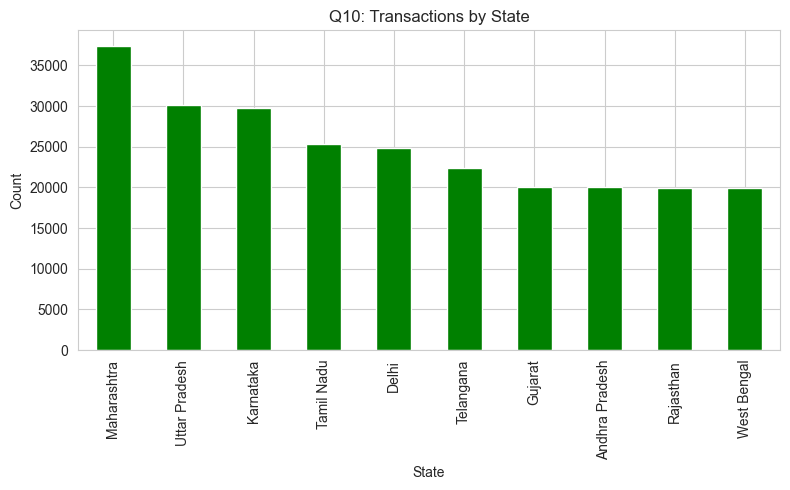

In [43]:

state_count = df["sender_state"].value_counts()

plt.figure(figsize=(8, 5))
state_count.plot(kind="bar", color="green")
plt.title("Q10: Transactions by State")
plt.xlabel("State")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("outputs/q10.png")
plt.show()



**Observation:** Transaction count is fairly even across all states, with a few leading states.
**Business Insight:** UPI usage is spread across the country, not just one region.
**Recommendation:** Spread customer support resources across all major states.


### Question 11: Which sender bank has the most transactions?

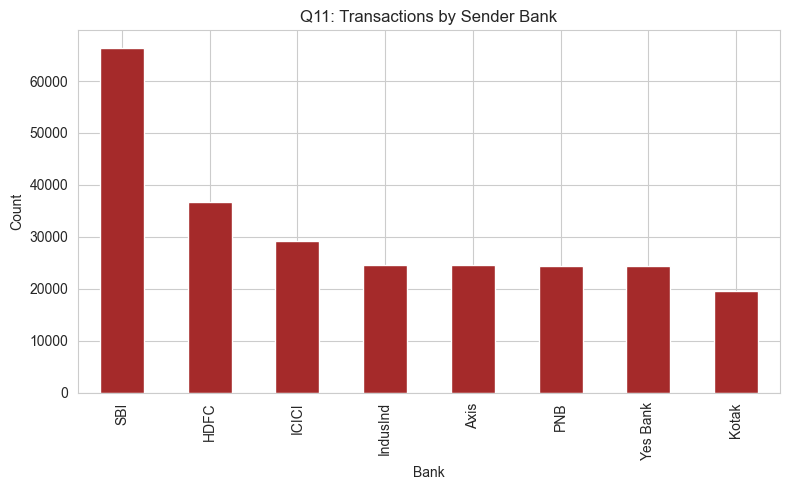

In [44]:

bank_count = df["sender_bank"].value_counts()

plt.figure(figsize=(8, 5))
bank_count.plot(kind="bar", color="brown")
plt.title("Q11: Transactions by Sender Bank")
plt.xlabel("Bank")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("outputs/q11.png")
plt.show()



**Observation:** A few large banks handle most of the sending transactions.
**Business Insight:** These banks are key partners for UPI reliability.
**Recommendation:** Ensure strong technical support and uptime with top banks.


### Question 12: Which device type has the highest failure rate?

<Figure size 800x500 with 0 Axes>

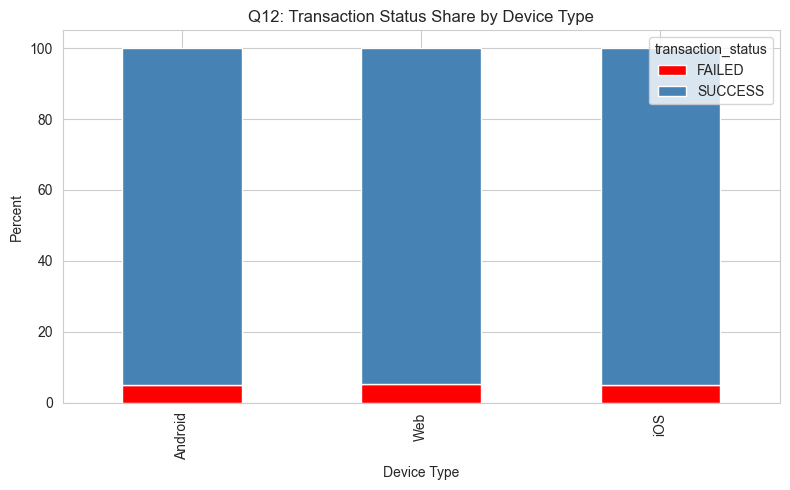

In [45]:

device_status = pd.crosstab(df["device_type"], df["transaction_status"], normalize="index") * 100

plt.figure(figsize=(8, 5))
device_status.plot(kind="bar", stacked=True, color=["red", "steelblue"])
plt.title("Q12: Transaction Status Share by Device Type")
plt.xlabel("Device Type")
plt.ylabel("Percent")
plt.tight_layout()
plt.savefig("outputs/q12.png")
plt.show()



**Observation:** Failure rate is close to the same across Android, iOS, and Web.
**Business Insight:** Device type is not a major reason for transaction failure.
**Recommendation:** Look at network and bank systems instead of device apps for fixing failures.


### Question 13: Which merchant category has the highest fraud rate?

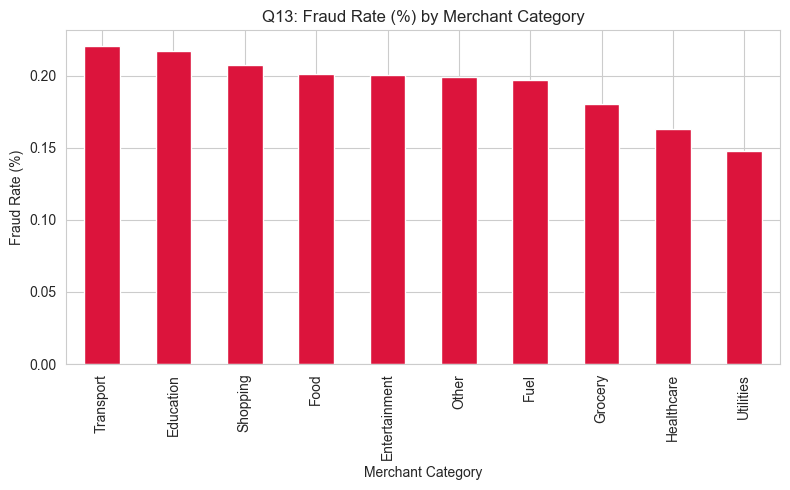

In [46]:

fraud_by_category = (df.groupby("merchant_category")["fraud_flag"].mean() * 100).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
fraud_by_category.plot(kind="bar", color="crimson")
plt.title("Q13: Fraud Rate (%) by Merchant Category")
plt.xlabel("Merchant Category")
plt.ylabel("Fraud Rate (%)")
plt.tight_layout()
plt.savefig("outputs/q13.png")
plt.show()



**Observation:** Fraud rate is higher in a few categories than others.
**Business Insight:** Fraud risk is not the same everywhere; some categories need more care.
**Recommendation:** Apply stronger fraud checks for the top risky categories.


### Question 14: Which network type has the highest fraud rate?

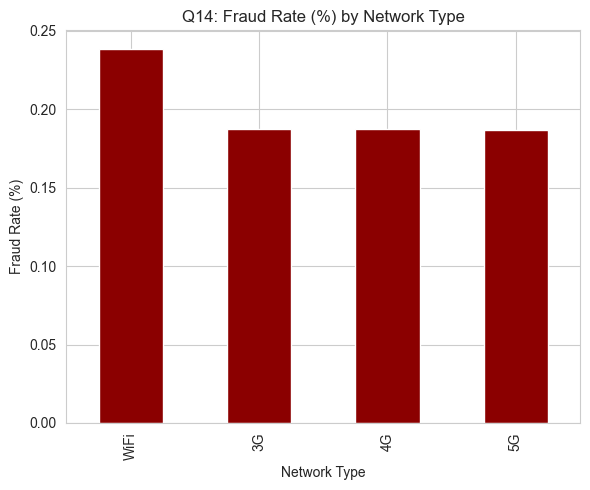

In [47]:

fraud_by_network = (df.groupby("network_type")["fraud_flag"].mean() * 100).sort_values(ascending=False)

plt.figure(figsize=(6, 5))
fraud_by_network.plot(kind="bar", color="darkred")
plt.title("Q14: Fraud Rate (%) by Network Type")
plt.xlabel("Network Type")
plt.ylabel("Fraud Rate (%)")
plt.tight_layout()
plt.savefig("outputs/q14.png")
plt.show()



**Observation:** Fraud rate is a little higher on WiFi compared to mobile networks.
**Business Insight:** Public or weak WiFi may carry more risk.
**Recommendation:** Add extra security checks for WiFi-based transactions.


### Question 15: What is the share of each sender age group?

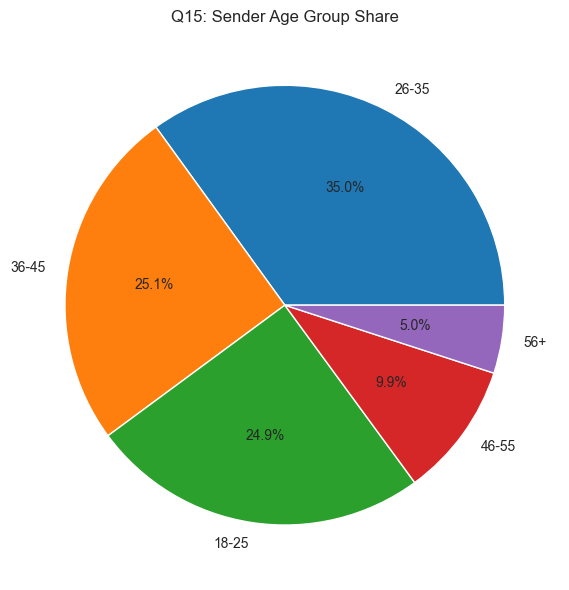

In [48]:

age_count = df["sender_age_group"].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(age_count.values, labels=age_count.index, autopct="%1.1f%%")
plt.title("Q15: Sender Age Group Share")
plt.tight_layout()
plt.savefig("outputs/q15.png")
plt.show()



**Observation:** The 26-35 age group has the biggest share of transactions.
**Business Insight:** Working-age adults are the main UPI users.
**Recommendation:** Create financial literacy programs for older age groups to grow usage.


### Question 16: How do sender and receiver age groups relate?

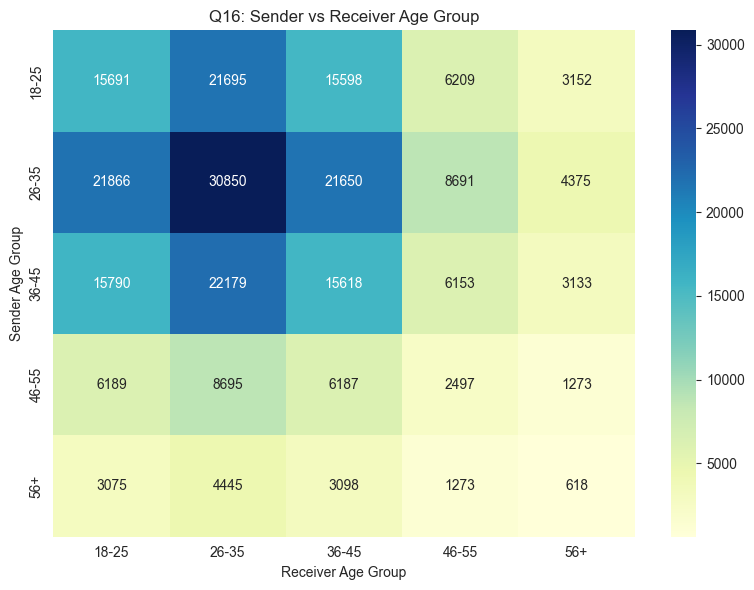

In [49]:

age_cross = pd.crosstab(df["sender_age_group"], df["receiver_age_group"])

plt.figure(figsize=(8, 6))
sns.heatmap(age_cross, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Q16: Sender vs Receiver Age Group")
plt.xlabel("Receiver Age Group")
plt.ylabel("Sender Age Group")
plt.tight_layout()
plt.savefig("outputs/q16.png")
plt.show()



**Observation:** Transactions happen between many different age group pairs.
**Business Insight:** Money moves across generations, not just within the same age group.
**Recommendation:** Consider family-linked payment features for cross-age transfers.


### Question 17: How do numeric columns correlate with each other?

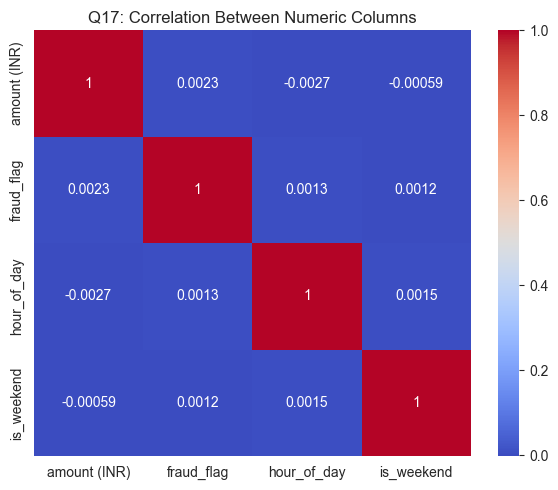

In [50]:

numeric_cols = ["amount (INR)", "fraud_flag", "hour_of_day", "is_weekend"]

plt.figure(figsize=(6, 5))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Q17: Correlation Between Numeric Columns")
plt.tight_layout()
plt.savefig("outputs/q17.png")
plt.show()



**Observation:** All correlation values are close to zero.
**Business Insight:** Amount, hour, and weekend do not strongly predict fraud by themselves.
**Recommendation:** Use category-based rules, not just numbers, to catch fraud.


### Question 18: Does transaction amount differ for fraud vs non-fraud cases?

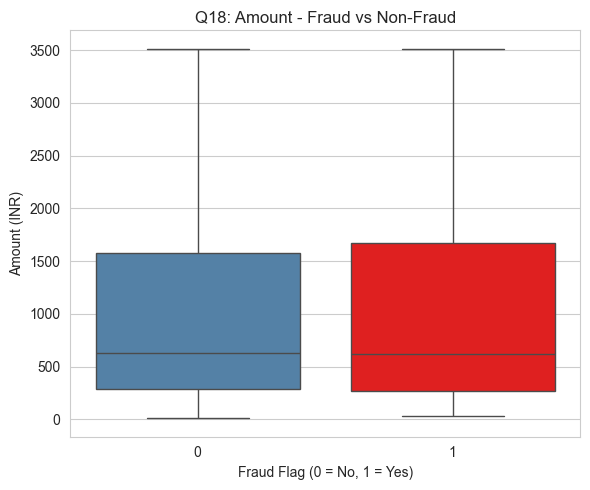

In [51]:

plt.figure(figsize=(6, 5))
sns.boxplot(data=df, x="fraud_flag", y="amount (INR)", palette=["steelblue", "red"])
plt.title("Q18: Amount - Fraud vs Non-Fraud")
plt.xlabel("Fraud Flag (0 = No, 1 = Yes)")
plt.ylabel("Amount (INR)")
plt.tight_layout()
plt.savefig("outputs/q18.png")
plt.show()



**Observation:** Fraud and non-fraud transactions have a similar amount range.
**Business Insight:** Fraud is not only about high amounts; small transactions can be fraud too.
**Recommendation:** Do not rely on amount alone to flag fraud transactions.


### Question 19: Which state has the highest transaction failure rate?

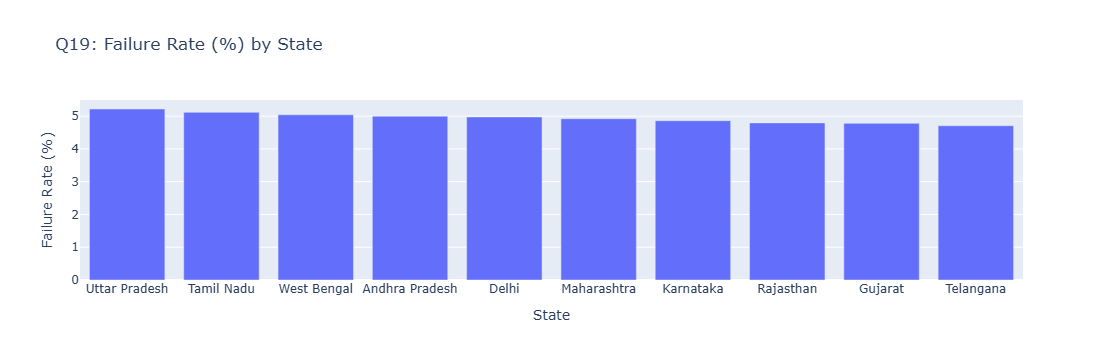

In [52]:

state_failure = df.groupby("sender_state").apply(lambda x: (x["transaction_status"] == "FAILED").mean() * 100)
state_failure = state_failure.sort_values(ascending=False).reset_index()
state_failure.columns = ["state", "failure_rate"]

fig = px.bar(state_failure, x="state", y="failure_rate",
             title="Q19: Failure Rate (%) by State",
             labels={"state": "State", "failure_rate": "Failure Rate (%)"})
fig.show()



**Observation:** Failure rate is a little higher in some states than others.
**Business Insight:** A few states may have weaker network or bank infrastructure.
**Recommendation:** Improve technical infrastructure in the highest failure-rate states.


### Question 20: What is the quarterly trend of total transaction value?

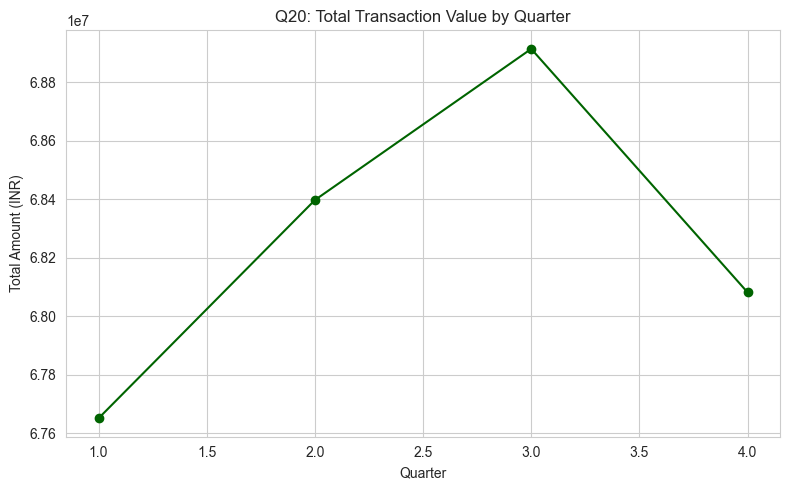

In [53]:

quarterly_value = df.groupby("quarter")["amount (INR)"].sum()

plt.figure(figsize=(8, 5))
quarterly_value.plot(kind="line", marker="o", color="darkgreen")
plt.title("Q20: Total Transaction Value by Quarter")
plt.xlabel("Quarter")
plt.ylabel("Total Amount (INR)")
plt.tight_layout()
plt.savefig("outputs/q20.png")
plt.show()



**Observation:** Total transaction value stays fairly stable across all four quarters.
**Business Insight:** The business has steady, predictable growth through the year.
**Recommendation:** Use this stable pattern as a baseline for future financial planning.



# 📝 PHASE 6 — Reporting & Insights

- This project analysed 252,500 raw UPI transaction records (250,000 after   de-duplication) spanning
- The full 2024 calendar year across 10 Indian states, 8 banks, 4          transaction types, and 10 merchant
- Removed duplicates, treated outliers, and created new time-based columns. We explored the
data with charts and answered 20 business questions covering usage, failures, and fraud.

- The data shows a mature, everyday-use digital payment ecosystem: usage   is dominated by small,
- frequent P2P/P2M transactions, is stable across days of the week and quarters, and shows only mild


## 6.1 Major Findings

1. Most transactions are small in value; median amount is about ₹629.
2. P2P (person-to-person) is the most used transaction type.
3. About 95% of transactions succeed; about 5% fail.
4. Overall fraud rate is very low, close to 0.19%.
5. Fraud rate is higher for some merchant categories and for WiFi network.
6. Transaction volume is steady across days, months, and quarters.
7. The 26-35 age group is the most active user group.
8. Device type does not affect failure rate much.



## 6.2 Recommendations

- Use category-specific and network-specific rules to catch fraud.
- Investigate failed transactions by state and bank to improve reliability.
- Keep systems ready every day of the week; usage does not drop on weekends.
- Offer different rewards or fees based on transaction type.
- Create programs to bring more older-age users onto UPI.



## 6.3 Future Scope

- Build a machine learning model to predict fraud automatically.
- Study more years of data to check for seasonal trends.
- Build a live dashboard using Streamlit for business teams.
- Add transaction fee or revenue data for deeper analysis.



## 6.4 Conclusion

This project cleaned and explored a large UPI transaction dataset and answered 20 business
questions using simple Python code and clear charts. The analysis shows that UPI is mainly
used for small daily payments, is highly reliable, and has a low but uneven fraud pattern
across categories and networks. These findings can help a payments company improve
reliability and reduce fraud risk.



## 6.5 References

- Dataset: UPI Digital Transactions Dataset (course-provided CSV file)
- Python Libraries: Pandas, NumPy, Matplotlib, Seaborn, Plotly
- Project Guideline: Cranes Varsity - Data Analysis & Visualization using Python



##  Thank You

Thank you for reading this project notebook.
